# Aula 5: evolução do IDH por estado

Nesta aula você abre a `Tabela4.csv` (IDHM por Unidade da Federação) e desenha um gráfico de linhas com **matplotlib**.

**O que vamos ver**

1. Abrir um CSV com `;` e vírgula decimal
2. Limpar colunas vazias
3. Ordenar os estados por maior IDH em 2024
4. Qual estado teve a maior melhora de IDH entre os anos de 1991 e 2024?
5. Existe algum estado em que o IDH piorou?
6. Passar a tabela inicial do formato largo para o formato longo (`melt`)
7. Plotar apenas Minas Gerais
8. Plotar a evolução do IDH de cada estado


In [1]:
# No terminal, uma vez: python -m pip install pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
path = r"H:\dados5\python-tecTI\dados\Tabela4.csv"

In [3]:
df = pd.read_csv(path, sep=";", skiprows=1, decimal=",", encoding="latin-1")
df.head()


,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [4]:
df = df.dropna(axis=1, how="all")
df.head()


,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sigla   27 non-null     str    
 1   Código  27 non-null     int64  
 2   Estado  27 non-null     str    
 3   1991    27 non-null     float64
 4   2000    27 non-null     float64
 5   2010    27 non-null     float64
 6   2012    27 non-null     float64
 7   2013    27 non-null     float64
 8   2014    27 non-null     float64
 9   2015    27 non-null     float64
 10  2016    27 non-null     float64
 11  2017    27 non-null     float64
 12  2018    27 non-null     float64
 13  2019    27 non-null     float64
 14  2020    27 non-null     float64
 15  2021    27 non-null     float64
 16  2022    27 non-null     float64
 17  2023    27 non-null     float64
 18  2024    27 non-null     float64
dtypes: float64(16), int64(1), str(2)
memory usage: 4.1 KB


In [6]:
df_2024 = df.sort_values("2024", ascending=False)
df_2024[["Sigla", "Estado", "2024"]]


,Sigla,Estado,2024
6,DF,Distrito Federal,0.866
25,SP,São Paulo,0.838
23,SC,Santa Catarina,0.833
17,PR,Paraná,0.822
18,RJ,Rio de Janeiro,0.819
22,RS,Rio Grande do Sul,0.818
8,GO,Goiás,0.815
12,MT,Mato Grosso,0.812
10,MG,Minas Gerais,0.809
7,ES,Espírito Santo,0.804


In [7]:
df["Melhora"] = df["2024"] - df["1991"]
df.sort_values("Melhora", ascending=False)[["Sigla", "Estado", "1991", "2024", "Melhora"]]


,Sigla,Estado,1991,2024,Melhora
26,TO,Tocantins,0.369,0.797,0.428
16,PI,Piauí,0.362,0.764,0.402
9,MA,Maranhão,0.357,0.745,0.388
20,RO,Rondônia,0.407,0.786,0.379
14,PB,Paraíba,0.382,0.760,0.378
1,AL,Alagoas,0.370,0.746,0.376
4,BA,Bahia,0.386,0.759,0.373
5,CE,Ceará,0.405,0.773,0.368
12,MT,Mato Grosso,0.449,0.812,0.363
24,SE,Sergipe,0.408,0.761,0.353


In [8]:
pioraram = df[df["Melhora"] < 0]
print(f"Número de estados que pioraram: {len(pioraram)}")
pioraram[["Sigla", "Estado", "1991", "2024", "Melhora"]]


Número de estados que pioraram: 0


,Sigla,Estado,1991,2024,Melhora


In [9]:
anos = [c for c in df.columns if str(c).isdigit()]
print(anos)

id_vars = [c for c in df.columns if c not in anos]
df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")
df_longo.head()


['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,Sigla,Código,Estado,Melhora,Ano,IDH
0,AC,12,Acre,0.352,1991,0.402
1,AL,27,Alagoas,0.376,1991,0.370
2,AM,13,Amazonas,0.337,1991,0.430
3,AP,16,Amapá,0.287,1991,0.472
4,BA,29,Bahia,0.373,1991,0.386


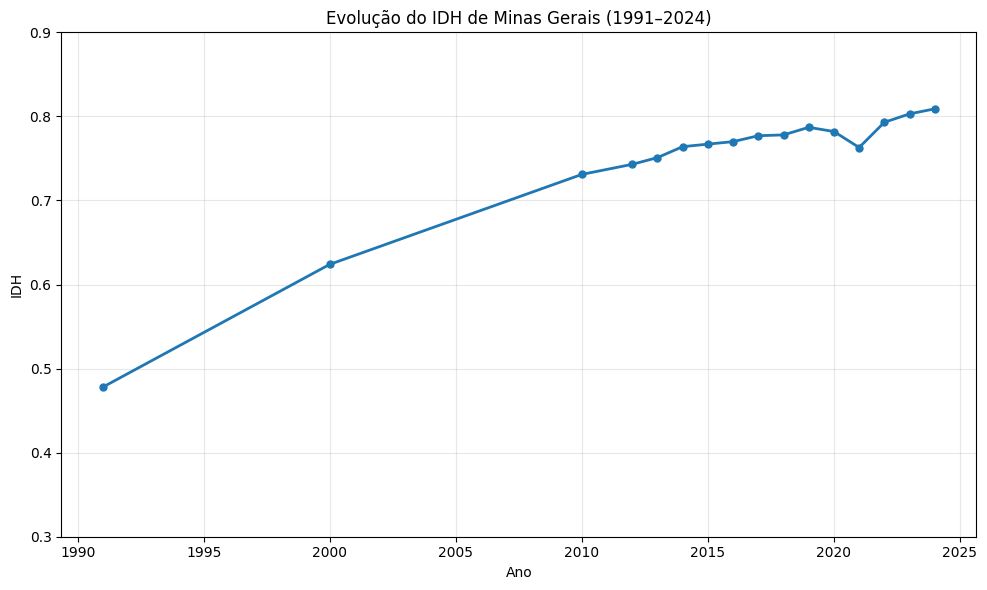

In [10]:
mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mg["Ano"], mg["IDH"], marker="o", markersize=5, linewidth=2, color="tab:blue")

ax.set_title("Evolução do IDH de Minas Gerais (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


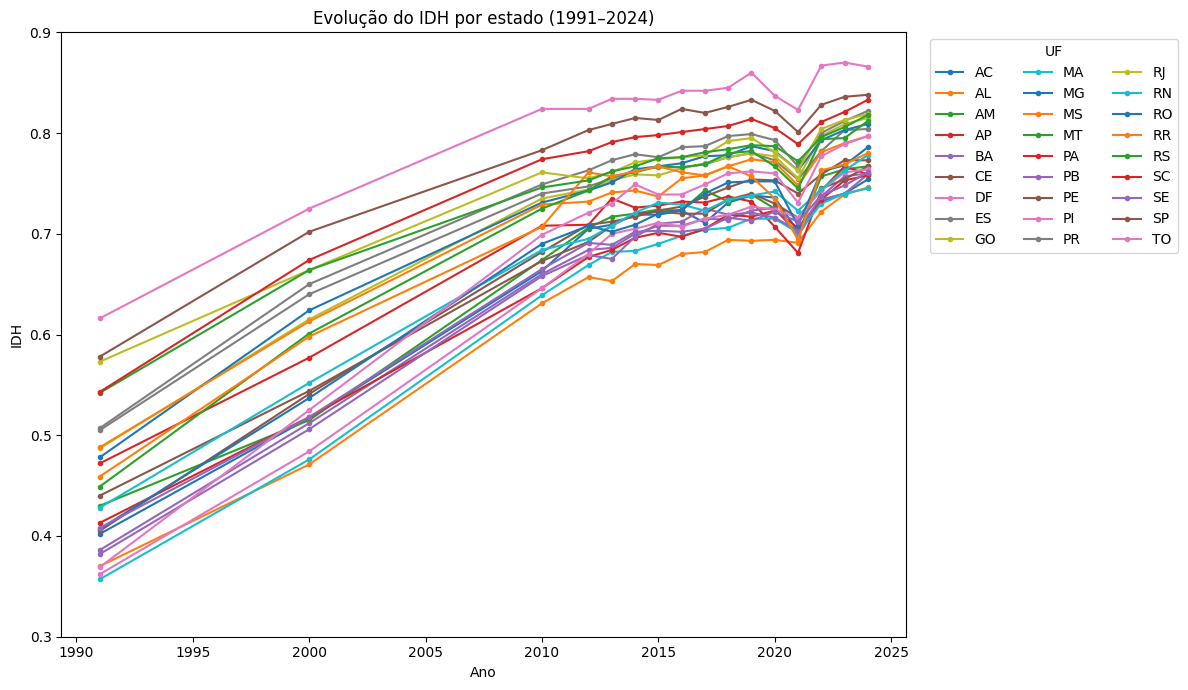

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()
